# Dynamic Pricing Model — Airbnb European Cities

## Problembeskrivelse
Airbnb-udlejere har svært ved at sætte den rigtige pris for deres bolig.
Sætter de prisen for høj, får de ingen bookinger.
Sætter de den for lav, mister de indtægt.

Dette projekt bygger en ML-model der kan forudsige en fair pris for en
Airbnb-bolig baseret på boligens karakteristika — såsom by, boligtype,
antal soveværelser og afstand til centrum.

## Datasæt
Airbnb Prices in European Cities fra Kaggle.
10 europæiske byer: Amsterdam, Athens, Barcelona, Berlin, Budapest,
Lisbon, London, Paris, Rome og Vienna.
51.571 boliger i alt.

## Metode
Vi træner og sammenligner 3 modeller:
1. **Linear Regression** — simpel baseline model
2. **Deep Neural Network (DNN)** — neural netværk med 3 skjulte lag
3. **XGBoost** — tree-based model

## Resultat
XGBoost er den bedste model med RMSE: 103 kr. og R²: 0.73 —
modellen er 73% tæt på den perfekte forudsigelse.

## Ekstra
Chat-løkke med Anthropic Claude API der lader brugeren spørge på
naturligt dansk og få en prisforudsigelse tilbage.

In [2]:
import pandas as pd
from google.colab import files

print("Upload din CSV fil:")
uploaded = files.upload()

Upload din CSV fil:


Saving amsterdam_weekdays.csv to amsterdam_weekdays.csv
Saving amsterdam_weekends.csv to amsterdam_weekends.csv
Saving athens_weekdays.csv to athens_weekdays.csv
Saving athens_weekends.csv to athens_weekends.csv
Saving barcelona_weekdays.csv to barcelona_weekdays.csv
Saving barcelona_weekends.csv to barcelona_weekends.csv
Saving berlin_weekdays.csv to berlin_weekdays.csv
Saving berlin_weekends.csv to berlin_weekends.csv
Saving budapest_weekdays.csv to budapest_weekdays.csv
Saving budapest_weekends.csv to budapest_weekends.csv
Saving lisbon_weekdays.csv to lisbon_weekdays.csv
Saving lisbon_weekends.csv to lisbon_weekends.csv
Saving london_weekdays.csv to london_weekdays.csv
Saving london_weekends.csv to london_weekends.csv
Saving paris_weekdays.csv to paris_weekdays.csv
Saving paris_weekends.csv to paris_weekends.csv
Saving rome_weekdays.csv to rome_weekdays.csv
Saving rome_weekends.csv to rome_weekends.csv
Saving vienna_weekdays.csv to vienna_weekdays.csv
Saving vienna_weekends.csv to 

In [33]:
import pandas as pd

# Indlæs alle 20 CSV filer og slå dem sammen
alle_filer = [
    'amsterdam_weekdays.csv', 'amsterdam_weekends.csv',
    'athens_weekdays.csv', 'athens_weekends.csv',
    'barcelona_weekdays.csv', 'barcelona_weekends.csv',
    'berlin_weekdays.csv', 'berlin_weekends.csv',
    'budapest_weekdays.csv', 'budapest_weekends.csv',
    'lisbon_weekdays.csv', 'lisbon_weekends.csv',
    'london_weekdays.csv', 'london_weekends.csv',
    'paris_weekdays.csv', 'paris_weekends.csv',
    'rome_weekdays.csv', 'rome_weekends.csv',
    'vienna_weekdays.csv', 'vienna_weekends.csv',
]

dfs = []
for fil in alle_filer:
    temp_df = pd.read_csv(fil)
    temp_df['city'] = fil.split('_')[0]        # tilføj by som kolonne
    temp_df['weekend'] = 1 if 'weekends' in fil else 0  # tilføj weekend som kolonne
    dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)

print(f"Samlet datasæt: {df.shape}")
print(f"Byer: {df['city'].unique()}")
df.head()

Samlet datasæt: (51707, 22)
Byer: ['amsterdam' 'athens' 'barcelona' 'berlin' 'budapest' 'lisbon' 'london'
 'paris' 'rome' 'vienna']


,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,...,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat,city,weekend
0,0,194.033698,Private room,False,True,2.0,False,1,0,10.0,...,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473,4.90569,52.41772,amsterdam,0
1,1,344.245776,Private room,False,True,4.0,False,0,0,8.0,...,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928,4.90005,52.37432,amsterdam,0
2,2,264.101422,Private room,False,True,2.0,False,0,1,9.0,...,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700,4.97512,52.36103,amsterdam,0
3,3,433.529398,Private room,False,True,4.0,False,0,1,9.0,...,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565,4.89417,52.37663,amsterdam,0
4,4,485.552926,Private room,False,True,2.0,True,0,0,10.0,...,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677,4.90051,52.37508,amsterdam,0


realSum er vores target — det er prisen vi vil forudsige


In [40]:
print("Manglende værdier:")
print(df.isnull().sum())
print()
print("Grundlæggende statistik:")
df.describe()

Manglende værdier:
realSum                       0
room_shared                   0
room_private                  0
person_capacity               0
host_is_superhost             0
multi                         0
biz                           0
cleanliness_rating            0
guest_satisfaction_overall    0
bedrooms                      0
dist                          0
metro_dist                    0
attr_index_norm               0
rest_index_norm               0
weekend                       0
city_amsterdam                0
city_athens                   0
city_barcelona                0
city_berlin                   0
city_budapest                 0
city_lisbon                   0
city_london                   0
city_paris                    0
city_rome                     0
city_vienna                   0
room_type_Entire home/apt     0
room_type_Private room        0
room_type_Shared room         0
dtype: int64

Grundlæggende statistik:


,realSum,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index_norm,rest_index_norm,weekend
count,51571.000000,51571.000000,51571.000000,51571.000000,51571.000000,51571.000000,51571.000000,51571.000000,51571.000000,51571.000000,51571.000000,51571.000000,51571.000000,51571.000000,51571.000000
mean,269.854510,0.007097,0.362122,3.158442,0.256132,0.291327,0.350585,9.390355,92.622385,1.155960,3.191564,0.681883,13.386606,22.782036,0.506777
std,197.556344,0.083945,0.480619,1.296513,0.436500,0.454378,0.477158,0.953859,8.937913,0.623572,2.394593,0.858871,9.727645,17.804090,0.499959
min,34.779339,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,20.000000,0.000000,0.015045,0.002301,0.926301,0.592757,0.000000
25%,148.639432,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,9.000000,90.000000,1.000000,1.453417,0.248396,6.372431,8.746666,0.000000
50%,210.906194,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,10.000000,95.000000,1.000000,2.614001,0.413204,11.453462,17.526904,1.000000
75%,318.529220,0.000000,1.000000,4.000000,1.000000,1.000000,1.000000,10.000000,99.000000,1.000000,4.262855,0.738435,17.389499,32.967769,1.000000
max,1997.515994,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,10.000000,100.000000,10.000000,25.284557,14.273577,100.000000,100.000000,1.000000


In [42]:
import pandas as pd

# Fjern outliers (priser over 2000 er ekstremer)
df = df[df['realSum'] < 2000]

# Fjern unødvendige kolonner
df = df.drop(columns=['Unnamed: 0', 'attr_index', 'rest_index', 'lng', 'lat'], errors='ignore')

# Konverter True/False til 1/0
df['room_shared'] = df['room_shared'].astype(int)
df['room_private'] = df['room_private'].astype(int)
df['host_is_superhost'] = df['host_is_superhost'].astype(int)

print(f"Kolonner nu: {df.columns.tolist()}")
print(f"Rækker: {len(df)}")

print(f"Rækker efter rensning: {len(df)}")
print(df.columns.tolist())
print(df.head())

Kolonner nu: ['realSum', 'room_shared', 'room_private', 'person_capacity', 'host_is_superhost', 'multi', 'biz', 'cleanliness_rating', 'guest_satisfaction_overall', 'bedrooms', 'dist', 'metro_dist', 'attr_index_norm', 'rest_index_norm', 'weekend', 'city_amsterdam', 'city_athens', 'city_barcelona', 'city_berlin', 'city_budapest', 'city_lisbon', 'city_london', 'city_paris', 'city_rome', 'city_vienna', 'room_type_Entire home/apt', 'room_type_Private room', 'room_type_Shared room']
Rækker: 51571
Rækker efter rensning: 51571
['realSum', 'room_shared', 'room_private', 'person_capacity', 'host_is_superhost', 'multi', 'biz', 'cleanliness_rating', 'guest_satisfaction_overall', 'bedrooms', 'dist', 'metro_dist', 'attr_index_norm', 'rest_index_norm', 'weekend', 'city_amsterdam', 'city_athens', 'city_barcelona', 'city_berlin', 'city_budapest', 'city_lisbon', 'city_london', 'city_paris', 'city_rome', 'city_vienna', 'room_type_Entire home/apt', 'room_type_Private room', 'room_type_Shared room']
      

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['realSum'])
y = df['realSum']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Træningsdata: {X_train.shape}")
print(f"Testdata: {X_test.shape}")

Træningsdata: (41256, 27)
Testdata: (10315, 27)


Nu træner vi den første model — Linear Regression:

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Træn modellen
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Evaluer
y_pred_lr = lr_model.predict(X_test_scaled)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Linear Regression ===")
print(f"RMSE: {rmse_lr:.2f} kr.")
print(f"R²:   {r2_lr:.4f}")

=== Linear Regression ===
RMSE: 132.44 kr.
R²:   0.5523


Nu træner vi den anden model -  XGBoost

In [53]:
from xgboost import XGBRegressor

# Træn modellen
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# Evaluer
y_pred_xgb = xgb_model.predict(X_test_scaled)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("=== XGBoost ===")
print(f"RMSE: {rmse_xgb:.2f} kr.")
print(f"R²:   {r2_xgb:.4f}")

=== XGBoost ===
RMSE: 103.74 kr.
R²:   0.7253


Nu træner vi den sidste — DNN:

In [54]:
import tensorflow as tf
from tensorflow import keras

# Byg DNN model (opdateret)
dnn_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

dnn_model.compile(optimizer='adam', loss='mse')

# Træn modellen (færre epochs = hurtigere)
history = dnn_model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Evaluer
y_pred_dnn = dnn_model.predict(X_test_scaled).flatten()
rmse_dnn = np.sqrt(mean_squared_error(y_test, y_pred_dnn))
r2_dnn = r2_score(y_test, y_pred_dnn)

print("=== DNN ===")
print(f"RMSE: {rmse_dnn:.2f} kr.")
print(f"R²:   {r2_dnn:.4f}")

Epoch 1/20
581/581 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 27725.7773 - val_loss: 13055.6162
Epoch 2/20
581/581 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 14275.4238 - val_loss: 12450.9072
Epoch 3/20
581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13985.8477 - val_loss: 12589.1914
Epoch 4/20
581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13806.2939 - val_loss: 12245.0127
Epoch 5/20
581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13665.3535 - val_loss: 12449.4580
Epoch 6/20
581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13551.9238 - val_loss: 12014.5381
Epoch 7/20
581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13433.3838 - val_loss: 11958.1191
Epoch 8/20
581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13377.1143 - val_loss: 12076.0107
Epoch 9/20
581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13293.6484 - val_loss: 11806.0713
Epoch 10/20
581/581 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 13220.0889 - val_loss: 11622.1758
Epoch 11/20
581/581 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss

In [55]:
print("========================================")
print("       SAMMENLIGNING AF MODELLER        ")
print("========================================")
print(f"{'Model':<20} {'RMSE':<15} {'R²'}")
print("-" * 40)
print(f"{'Linear Regression':<20} {rmse_lr:<15.2f} {r2_lr:.4f}")
print(f"{'DNN':<20} {rmse_dnn:<15.2f} {r2_dnn:.4f}")
print(f"{'XGBoost':<20} {rmse_xgb:<15.2f} {r2_xgb:.4f}")
print("========================================")
print(f"\nBedste model: XGBoost")
print(f"XGBoost har lavest RMSE og højest R²")

       SAMMENLIGNING AF MODELLER        
Model                RMSE            R²
----------------------------------------
Linear Regression    132.44          0.5523
DNN                  110.10          0.6906
XGBoost              103.74          0.7253

Bedste model: XGBoost
XGBoost har lavest RMSE og højest R²


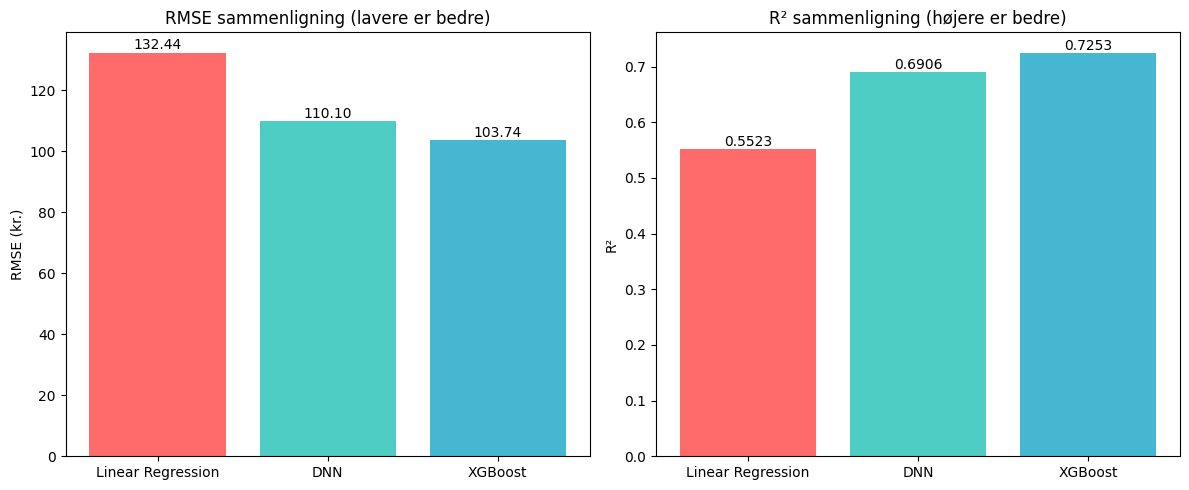

In [56]:
import matplotlib.pyplot as plt

modeller = ['Linear Regression', 'DNN', 'XGBoost']
rmse_værdier = [rmse_lr, rmse_dnn, rmse_xgb]
r2_værdier = [r2_lr, r2_dnn, r2_xgb]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# RMSE graf (lavere er bedre)
ax1.bar(modeller, rmse_værdier, color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
ax1.set_title('RMSE sammenligning (lavere er bedre)')
ax1.set_ylabel('RMSE (kr.)')
for i, v in enumerate(rmse_værdier):
    ax1.text(i, v + 1, f'{v:.2f}', ha='center')

# R² graf (højere er bedre)
ax2.bar(modeller, r2_værdier, color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
ax2.set_title('R² sammenligning (højere er bedre)')
ax2.set_ylabel('R²')
for i, v in enumerate(r2_værdier):
    ax2.text(i, v + 0.005, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.savefig('model_sammenligning.png')
plt.show()

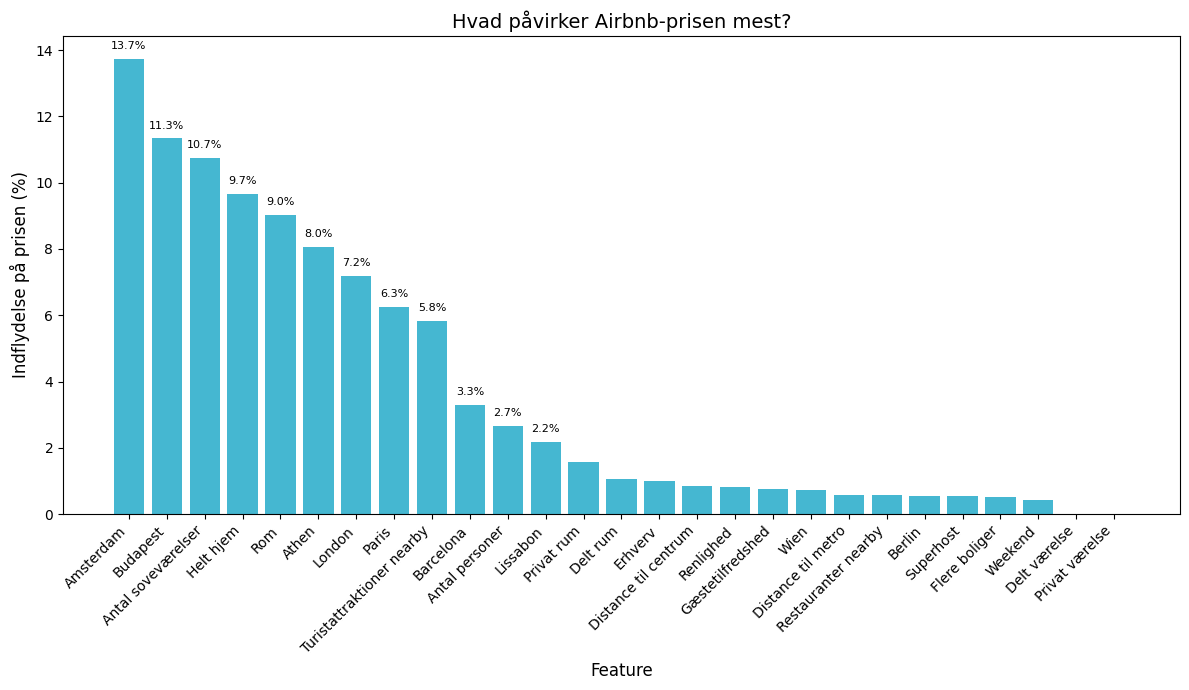

In [57]:
# Bedre navne til features
feature_navne = {
    'city_amsterdam': 'Amsterdam',
    'city_budapest': 'Budapest',
    'city_rome': 'Rom',
    'city_athens': 'Athen',
    'city_london': 'London',
    'city_paris': 'Paris',
    'city_barcelona': 'Barcelona',
    'city_lisbon': 'Lissabon',
    'city_vienna': 'Wien',
    'city_berlin': 'Berlin',
    'room_type_Entire home/apt': 'Helt hjem',
    'room_type_Private room': 'Privat værelse',
    'room_type_Shared room': 'Delt værelse',
    'bedrooms': 'Antal soveværelser',
    'person_capacity': 'Antal personer',
    'dist': 'Distance til centrum',
    'metro_dist': 'Distance til metro',
    'attr_index_norm': 'Turistattraktioner nearby',
    'rest_index_norm': 'Restauranter nearby',
    'cleanliness_rating': 'Renlighed',
    'guest_satisfaction_overall': 'Gæstetilfredshed',
    'host_is_superhost': 'Superhost',
    'multi': 'Flere boliger',
    'biz': 'Erhverv',
    'weekend': 'Weekend',
    'room_shared': 'Delt rum',
    'room_private': 'Privat rum',
}

feature_names = X.columns.tolist()
importances = xgb_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

labels = [feature_navne.get(feature_names[i], feature_names[i]) for i in sorted_idx]

plt.figure(figsize=(12, 7))
plt.bar(range(len(importances)), importances[sorted_idx] * 100, color='#45b7d1')
plt.xticks(range(len(importances)), labels, rotation=45, ha='right')
plt.title('Hvad påvirker Airbnb-prisen mest?', fontsize=14)
plt.ylabel('Indflydelse på prisen (%)', fontsize=12)
plt.xlabel('Feature', fontsize=12)

for i, v in enumerate(importances[sorted_idx] * 100):
    if v > 2:
        plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

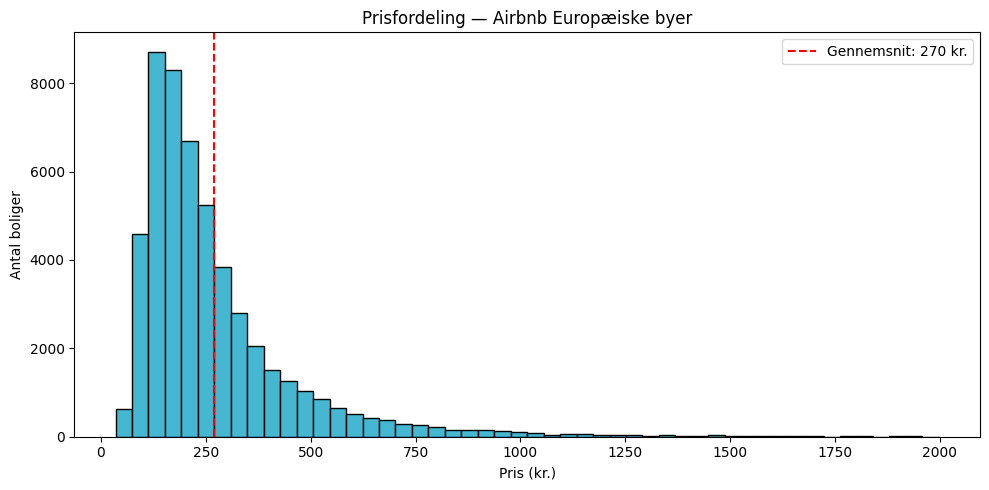

In [58]:
plt.figure(figsize=(10, 5))
plt.hist(df['realSum'], bins=50, color='#45b7d1', edgecolor='black')
plt.title('Prisfordeling — Airbnb Europæiske byer')
plt.xlabel('Pris (kr.)')
plt.ylabel('Antal boliger')
plt.axvline(df['realSum'].mean(), color='red', linestyle='--', label=f'Gennemsnit: {df["realSum"].mean():.0f} kr.')
plt.legend()
plt.tight_layout()
plt.savefig('prisfordeling.png')
plt.show()

In [23]:
!pip install anthropic -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.0/833.0 kB 12.7 MB/s eta 0:00:00


In [59]:


from google.colab import userdata
import anthropic
import json

client = anthropic.Anthropic(api_key=userdata.get('ANTHROPIC_API_KEY'))

def fortolk_spoergsmaal(spoergsmaal: str) -> dict:
    """Bruger Claude til at fortolke udlejerens spørgsmål og udtrække features."""
    svar = client.messages.create(
        model='claude-haiku-4-5',
        max_tokens=512,
        messages=[{
            'role': 'user',
            'content': f"""Du er en assistent der hjælper Airbnb-udlejere med at sætte den rette pris.

Udtræk følgende information og returner KUN valid JSON uden forklaring eller markdown:
{{
    "room_type": "Entire home/apt" eller "Private room" eller "Shared room",
    "city": "amsterdam", "athens", "barcelona", "berlin", "budapest", "lisbon", "london", "paris", "rome" eller "vienna",
    "person_capacity": antal personer (2-6),
    "bedrooms": antal soveværelser (1-8),
    "dist": distance til centrum i km (1-10),
    "metro_dist": distance til metro i km (0.1-3),
    "host_is_superhost": 0 eller 1,
    "cleanliness_rating": 9,
    "guest_satisfaction_overall": 90,
    "multi": 0,
    "biz": 0,
    "attr_index_norm": 20,
    "rest_index_norm": 10
}}

Standardværdier hvis information mangler:
- room_type: "Private room"
- city: "london"
- person_capacity: 2
- bedrooms: 1
- dist: 3
- metro_dist: 0.5

Brugerens spørgsmål: {spoergsmaal}"""
        }]
    )
    tekst = svar.content[0].text.strip()
    tekst = tekst.replace('```json', '').replace('```', '').strip()
    return json.loads(tekst)


def forudsig_pris(features: dict) -> float:
    """Bruger XGBoost modellen til at forudsige prisen."""
    input_data = {col: 0 for col in X.columns}

    # Sæt room_type
    if features['room_type'] == 'Entire home/apt':
        input_data['room_type_Entire home/apt'] = 1
        input_data['room_shared'] = 0
        input_data['room_private'] = 0
    elif features['room_type'] == 'Private room':
        input_data['room_type_Private room'] = 1
        input_data['room_shared'] = 0
        input_data['room_private'] = 1
    else:
        input_data['room_type_Shared room'] = 1
        input_data['room_shared'] = 1
        input_data['room_private'] = 0

    # Sæt by
    city_col = f"city_{features.get('city', 'london')}"
    if city_col in input_data:
        input_data[city_col] = 1

    # Sæt resten
    for key in ['person_capacity', 'bedrooms', 'dist', 'metro_dist',
                'host_is_superhost', 'cleanliness_rating',
                'guest_satisfaction_overall', 'multi', 'biz',
                'attr_index_norm', 'rest_index_norm']:
        if key in input_data:
            input_data[key] = features[key]

    input_df = pd.DataFrame([input_data])
    input_scaled = scaler.transform(input_df)
    pris = xgb_model.predict(input_scaled)[0]
    return pris


# Chat løkke
print("=" * 55)
print("  Airbnb Pris-forudsigelse — Europæiske byer")
print("  Primært til udlejere der vil sætte den rette pris")
print("=" * 55)
print("\nUnderstøttede byer:")
print("  Amsterdam, Athen, Barcelona, Berlin, Budapest,")
print("  Lissabon, London, Paris, Rom, Wien")
print("\nEksempler på spørgsmål:")
print("  - Jeg har et helt hjem med 2 soveværelser i London 1 km fra centrum")
print("  - Hvad er en fair pris for et privat værelse i Amsterdam til 2 personer?")
print("  - Jeg udlejer et værelse i Paris 3 km fra centrum")
print("\nSkriv 'afslut' for at stoppe")
print("=" * 55)

while True:
    spoergsmaal = input("\nDu: ").strip()

    if spoergsmaal.lower() in ('afslut', 'quit', 'exit', 'q'):
        print("Chat afsluttet.")
        break
    if not spoergsmaal:
        continue

    try:
        features = fortolk_spoergsmaal(spoergsmaal)
        pris = forudsig_pris(features)

        print(f"\n[Fortolket]")
        print(f"  By          : {features.get('city', 'london').capitalize()}")
        print(f"  Boligtype   : {features['room_type']}")
        print(f"  Personer    : {features['person_capacity']}")
        print(f"  Soveværelser: {features['bedrooms']}")
        print(f"  Dist centrum: {features['dist']} km")
        print(f"\n💰 Forventet pris: {pris:.0f} kr. per nat")
        print(f"  (Gennemsnitlig fejlmargin: ±101 kr.)")

    except Exception as e:
        print(f"Fejl: {e} — prøv at formuler spørgsmålet anderledes")

  Airbnb Pris-forudsigelse — Europæiske byer
  Primært til udlejere der vil sætte den rette pris

Understøttede byer:
  Amsterdam, Athen, Barcelona, Berlin, Budapest,
  Lissabon, London, Paris, Rom, Wien

Eksempler på spørgsmål:
  - Jeg har et helt hjem med 2 soveværelser i London 1 km fra centrum
  - Hvad er en fair pris for et privat værelse i Amsterdam til 2 personer?
  - Jeg udlejer et værelse i Paris 3 km fra centrum

Skriv 'afslut' for at stoppe

Du: Hvad er en fair pris for et privat værelse i Amsterdam til 2 personer?

[Fortolket]
  By          : Amsterdam
  Boligtype   : Private room
  Personer    : 2
  Soveværelser: 1
  Dist centrum: 3 km

💰 Forventet pris: 334 kr. per nat
  (Gennemsnitlig fejlmargin: ±101 kr.)

Du: afslut
Chat afsluttet.
